Original shape: (150, 4)
Scaled shape: (150, 4)

Covariance matrix:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]

Eigenvalues:
[0.02085386 0.14774182 0.9201649  2.93808505]

Eigenvectors:
[[ 0.26128628  0.71956635  0.37741762 -0.52106591]
 [-0.12350962 -0.24438178  0.92329566  0.26934744]
 [-0.80144925 -0.14212637  0.02449161 -0.5804131 ]
 [ 0.52359713 -0.63427274  0.06694199 -0.56485654]]

Sorted eigenvalues:
[2.93808505 0.9201649  0.14774182 0.02085386]

Explained variance ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative explained variance:
[0.72962445 0.95813207 0.99482129 1.        ]

Selected principal components:
[[-0.52106591  0.37741762]
 [ 0.26934744  0.92329566]
 [-0.5804131   0.02449161]
 [-0.56485654  0.06694199]]

Reduced shape: (150, 2)


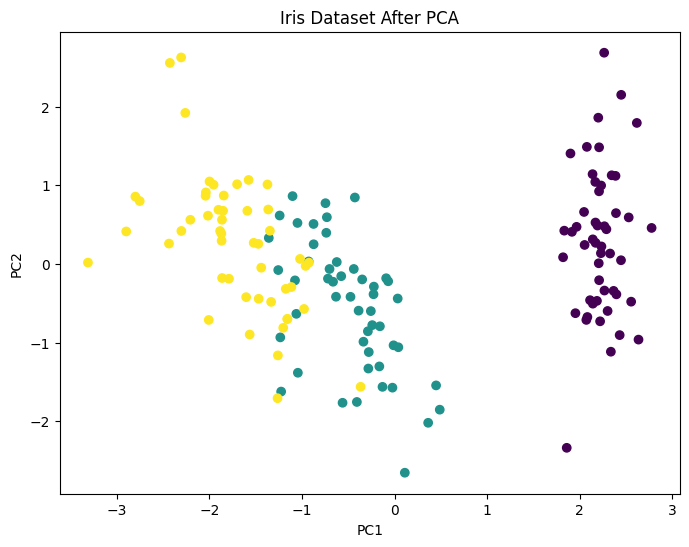


Sklearn PCA shape: (150, 2)

Sklearn explained variance:
[2.93808505 0.9201649 ]

Sklearn explained variance ratio:
[0.72962445 0.22850762]

Components:
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

Mean:
[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]

Components needed for 95% variance: 2
Reduced shape: (150, 2)


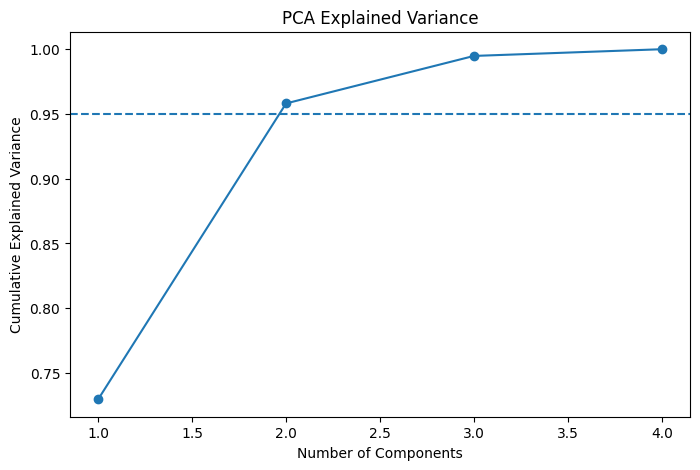


Accuracy with PCA: 0.9


In [1]:
# ============================================================
# PCA — PRINCIPAL COMPONENT ANALYSIS 🔴
# ============================================================
#
# DEPTH:
#   🔴 Deep
#
# PCA is one of the most important dimensionality reduction
# techniques for ML interviews.
#
# We will understand:
#
#   1. Why dimensionality reduction?
#   2. What PCA actually does
#   3. Intuition
#   4. Variance
#   5. Covariance
#   6. Covariance matrix
#   7. Eigenvectors
#   8. Eigenvalues
#   9. Principal components
#  10. Step-by-step PCA
#  11. Numerical example
#  12. Explained variance
#  13. sklearn PCA
#  14. PCA from scratch
#  15. Important parameters
#  16. Choosing number of components
#  17. Visualization
#  18. PCA + ML pipeline
#  19. Limitations
#  20. PCA vs LDA
#  21. PCA vs t-SNE
#  22. PCA vs UMAP
#  23. Interview questions
#  24. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score


# ============================================================
# 2. WHY DIMENSIONALITY REDUCTION?
# ============================================================
#
# Suppose we have:
#
#     1000 features
#
# But many of those features may contain overlapping or
# redundant information.
#
#
# Example:
#
#     Height
#     Weight
#     BMI
#     Waist size
#
#
# These features can contain correlated information.
#
#
# Instead of:
#
#     X = 1000 dimensions
#
# we may represent the important information using:
#
#     X = 50 dimensions
#
#
# This is dimensionality reduction.
#
#
# Benefits:
#
#     ✓ Reduce computation
#     ✓ Reduce memory
#     ✓ Remove redundancy
#     ✓ Help visualization
#     ✓ Sometimes reduce noise
#     ✓ Can help downstream ML models
#
# ============================================================


# ============================================================
# 3. WHAT IS PCA? ⭐⭐⭐
# ============================================================
#
# PCA finds NEW AXES that capture the maximum variance
# in the data.
#
#
# Original features:
#
#       X1
#       X2
#       X3
#       X4
#
#
# PCA creates:
#
#       PC1
#       PC2
#       PC3
#       ...
#
#
# These new axes are called:
#
#     Principal Components
#
#
# PC1:
#
#     Direction of maximum variance.
#
#
# PC2:
#
#     Direction of maximum remaining variance,
#     perpendicular to PC1.
#
#
# PC3:
#
#     Next maximum remaining variance,
#     perpendicular to previous components.
#
# ============================================================


# ============================================================
# 4. INTUITION ⭐⭐⭐
# ============================================================
#
# Imagine data like this:
#
#
#                    ●
#                 ●
#              ●
#           ●
#        ●
#     ●
#
#
# The data is spread mostly along a diagonal direction.
#
#
# Original axes:
#
#             X2
#             ↑
#             │
#             │      ●
#             │   ●
#             │ ●
#             └────────────→ X1
#
#
# But the important direction is actually:
#
#
#                  PC1
#                ↗
#              ↗
#            ↗
#
#
# PCA rotates the coordinate system so that:
#
#     PC1 captures maximum variance.
#
#
# If most information lies along PC1, we can discard
# the direction with very little variance.
#
# ============================================================


# ============================================================
# 5. WHAT DOES "VARIANCE" MEAN HERE?
# ============================================================
#
# Variance measures how spread out the data is.
#
#
# Formula:
#
#
#             1
# Var(X) = -------- Σ (x_i - μ)^2
#             n
#
#
# where:
#
#     μ = mean
#
#
# Intuition:
#
#     Large variance
#         ↓
#     Data is spread out
#
#
#     Small variance
#         ↓
#     Data is concentrated
#
#
# PCA tries to find directions where the data is spread out
# the most.
#
# ============================================================


# ============================================================
# 6. COVARIANCE ⭐⭐⭐
# ============================================================
#
# Variance tells us how ONE feature varies.
#
# Covariance tells us how TWO features vary together.
#
#
# Covariance:
#
#
#              1
# Cov(X,Y) = ----- Σ (x_i - μ_x)(y_i - μ_y)
#              n
#
#
# Positive covariance:
#
#     X increases → Y tends to increase.
#
#
# Negative covariance:
#
#     X increases → Y tends to decrease.
#
#
# Near zero:
#
#     Little linear relationship.
#
# ============================================================


# ============================================================
# 7. COVARIANCE MATRIX ⭐⭐⭐
# ============================================================
#
# Suppose we have two features:
#
#     X1
#     X2
#
#
# Covariance matrix:
#
#
#        [ Var(X1)      Cov(X1,X2) ]
#
# Σ =    [                      ]
#        [ Cov(X2,X1)   Var(X2)   ]
#
#
# For many features:
#
#
#             feature 1  feature 2  feature 3
#
# feature 1      Var       Cov        Cov
#
# feature 2      Cov       Var        Cov
#
# feature 3      Cov       Cov        Var
#
#
# PCA uses this covariance structure to find the directions
# of maximum variance.
#
# ============================================================


# ============================================================
# 8. THE KEY MATHEMATICAL IDEA ⭐⭐⭐
# ============================================================
#
# PCA performs eigendecomposition of the covariance matrix.
#
#
# Covariance matrix:
#
#     Σ
#
#
# Find:
#
#     Σv = λv
#
#
# where:
#
#     v = eigenvector
#     λ = eigenvalue
#
#
# Interpretation:
#
#
# EIGENVECTOR
#     ↓
# Direction of a principal component
#
#
# EIGENVALUE
#     ↓
# Amount of variance captured in that direction
#
#
# Therefore:
#
#     Largest eigenvalue
#           ↓
#     PC1
#
#
#     Second largest eigenvalue
#           ↓
#     PC2
#
#
# etc.
#
# ============================================================


# ============================================================
# 9. THE COMPLETE PCA MATHEMATICAL FLOW ⭐⭐⭐
# ============================================================
#
#
#                 DATA X
#                   │
#                   ▼
#             Center the data
#                   │
#                   ▼
#          Calculate covariance
#               matrix Σ
#                   │
#                   ▼
#          Eigendecomposition
#             Σv = λv
#                   │
#             ┌─────┴─────┐
#             ▼           ▼
#        Eigenvectors   Eigenvalues
#             │           │
#             │           └── Amount of variance
#             │
#             └── Directions
#                   │
#                   ▼
#          Sort by eigenvalue
#                   │
#                   ▼
#           Select top K
#          eigenvectors
#                   │
#                   ▼
#              Project X
#                   │
#                   ▼
#             Reduced data
#
# ============================================================


# ============================================================
# 10. STEP 1 — LOAD DATA
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

print(
    "Original shape:",
    X.shape
)


# ============================================================
# 11. STEP 2 — STANDARDIZATION ⭐⭐⭐
# ============================================================
#
# PCA is sensitive to feature scale.
#
#
# Example:
#
#     Feature 1 → 1 to 10
#
#     Feature 2 → 1 to 10,000
#
#
# Feature 2 could dominate the covariance.
#
#
# Therefore PCA is commonly performed after scaling.
#
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(
    "Scaled shape:",
    X_scaled.shape
)


# ============================================================
# 12. STEP 3 — CALCULATE COVARIANCE MATRIX
# ============================================================

cov_matrix = np.cov(
    X_scaled,
    rowvar=False
)

print(
    "\nCovariance matrix:"
)

print(
    cov_matrix
)


# ============================================================
# 13. STEP 4 — EIGENDECOMPOSITION
# ============================================================
#
# np.linalg.eigh() is appropriate for symmetric matrices
# such as covariance matrices.
#
# ============================================================

eigenvalues, eigenvectors = np.linalg.eigh(
    cov_matrix
)

print(
    "\nEigenvalues:"
)

print(
    eigenvalues
)


print(
    "\nEigenvectors:"
)

print(
    eigenvectors
)


# ============================================================
# 14. STEP 5 — SORT EIGENVALUES
# ============================================================
#
# np.linalg.eigh returns eigenvalues in ascending order.
#
# PCA needs:
#
#     largest eigenvalue first.
#
# ============================================================

sorted_indices = np.argsort(
    eigenvalues
)[::-1]

sorted_eigenvalues = eigenvalues[
    sorted_indices
]

sorted_eigenvectors = eigenvectors[
    :, sorted_indices
]

print(
    "\nSorted eigenvalues:"
)

print(
    sorted_eigenvalues
)


# ============================================================
# 15. STEP 6 — EXPLAINED VARIANCE
# ============================================================
#
# Each eigenvalue represents variance captured by that
# principal component.
#
#
# Explained variance ratio:
#
#
#        eigenvalue_i
# -------------------------
#      Σ all eigenvalues
#
# ============================================================

explained_variance_ratio = (
    sorted_eigenvalues
    /
    np.sum(sorted_eigenvalues)
)

print(
    "\nExplained variance ratio:"
)

print(
    explained_variance_ratio
)


print(
    "\nCumulative explained variance:"
)

print(
    np.cumsum(
        explained_variance_ratio
    )
)


# ============================================================
# 16. STEP 7 — SELECT TOP K COMPONENTS
# ============================================================
#
# Suppose we want:
#
#     2 dimensions
#
# Take the first two eigenvectors.
#
# ============================================================

k = 2

components = sorted_eigenvectors[
    :, :k
]

print(
    "\nSelected principal components:"
)

print(
    components
)


# ============================================================
# 17. STEP 8 — PROJECT DATA
# ============================================================
#
# This is the actual dimensionality reduction.
#
#
# Original:
#
#     X_scaled
#
# Shape:
#
#     (150, 4)
#
#
# Components:
#
#     (4, 2)
#
#
# Projection:
#
#
#     X_reduced = X_scaled × Components
#
#
# Result:
#
#     (150, 2)
#
# ============================================================

X_reduced = X_scaled @ components

print(
    "\nReduced shape:",
    X_reduced.shape
)


# ============================================================
# 18. VISUALIZE PCA RESULT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Iris Dataset After PCA"
)

plt.show()


# ============================================================
# 19. PCA FROM SCRATCH — COMPLETE FLOW ⭐⭐⭐
# ============================================================
#
# We have now implemented the mathematical PCA flow:
#
#
#     X
#     ↓
#     Standardize
#     ↓
#     Covariance matrix
#     ↓
#     Eigenvalues/eigenvectors
#     ↓
#     Sort eigenvalues
#     ↓
#     Select top K eigenvectors
#     ↓
#     X @ components
#     ↓
#     Reduced representation
#
#
# This is enough to reproduce the CORE PCA logic in an
# interview.
#
# ============================================================


# ============================================================
# 20. SKLEARN PCA ⭐⭐⭐
# ============================================================
#
# In production we normally use sklearn.
#
# ============================================================

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "\nSklearn PCA shape:",
    X_pca.shape
)


# ============================================================
# 21. COMPARE OUR PCA WITH SKLEARN
# ============================================================
#
# Eigenvector signs can be flipped without changing the
# mathematical solution.
#
# Therefore don't expect the exact sign/orientation to always
# match.
#
# The explained variance should match.
#
# ============================================================

print(
    "\nSklearn explained variance:"
)

print(
    pca.explained_variance_
)


print(
    "\nSklearn explained variance ratio:"
)

print(
    pca.explained_variance_ratio_
)


# ============================================================
# 22. IMPORTANT PCA ATTRIBUTES
# ============================================================
#
# pca.components_
#     Principal component directions.
#
#
# pca.explained_variance_
#     Variance captured by each component.
#
#
# pca.explained_variance_ratio_
#     Fraction of total variance captured.
#
#
# pca.n_components_
#     Number of selected components.
#
#
# pca.mean_
#     Mean used for centering.
#
#
# ============================================================

print(
    "\nComponents:"
)

print(
    pca.components_
)

print(
    "\nMean:"
)

print(
    pca.mean_
)


# ============================================================
# 23. CHOOSING NUMBER OF COMPONENTS ⭐⭐⭐
# ============================================================
#
# Instead of specifying:
#
#     n_components=2
#
# we can specify a variance threshold.
#
#
# Example:
#
#     n_components=0.95
#
#
# means:
#
#     Keep enough components to explain approximately 95%
#     of the variance.
#
# ============================================================

pca_95 = PCA(
    n_components=0.95
)

X_95 = pca_95.fit_transform(
    X_scaled
)

print(
    "\nComponents needed for 95% variance:",
    pca_95.n_components_
)


print(
    "Reduced shape:",
    X_95.shape
)


# ============================================================
# 24. CUMULATIVE EXPLAINED VARIANCE
# ============================================================

pca_full = PCA()

pca_full.fit(
    X_scaled
)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)


plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.show()


# ============================================================
# 25. PCA PARAMETERS ⭐⭐⭐
# ============================================================
#
#
# PCA(
#
#     n_components=None,
#     whiten=False,
#     svd_solver='auto',
#     tol=0.0,
#     iterated_power='auto',
#     random_state=None
#
# )
#
#
# ------------------------------------------------------------
# n_components ⭐⭐⭐
# ------------------------------------------------------------
#
# Number of dimensions to keep.
#
#
# Example:
#
#     n_components=2
#
# keeps 2 components.
#
#
# Or:
#
#     n_components=0.95
#
# keeps enough components to explain 95% variance.
#
#
# ------------------------------------------------------------
# whiten ⭐⭐
# ------------------------------------------------------------
#
# If True, components are scaled so that their output
# variances are approximately equal to 1.
#
#
# Usually:
#
#     whiten=False
#
# is fine unless a downstream algorithm benefits from
# whitening.
#
#
# ------------------------------------------------------------
# svd_solver ⭐⭐
# ------------------------------------------------------------
#
# Controls how PCA is computed.
#
# Common options:
#
#     "auto"
#     "full"
#     "randomized"
#     "arpack"
#
#
# "randomized" can be useful for large matrices when only a
# subset of components is required.
#
#
# ------------------------------------------------------------
# tol
# ------------------------------------------------------------
#
# Used for certain SVD solvers.
#
#
# ------------------------------------------------------------
# random_state
# ------------------------------------------------------------
#
# Controls randomness for randomized computations.
#
# ============================================================


# ============================================================
# 26. PCA USING SVD ⭐⭐⭐
# ============================================================
#
# In practical implementations, PCA is commonly computed
# using Singular Value Decomposition rather than explicitly
# calculating the covariance matrix and eigenvectors.
#
#
# For centered X:
#
#
#     X = U Σ Vᵀ
#
#
# The rows of Vᵀ correspond to principal directions.
#
#
# Singular values are related to the variance captured.
#
#
# Important interview point:
#
#     PCA can be computed through eigendecomposition of the
#     covariance matrix OR through SVD of the centered data.
#
# SVD is generally preferred numerically.
#
# ============================================================


# ============================================================
# 27. PCA + LOGISTIC REGRESSION
# ============================================================
#
# PCA can be placed before a supervised model.
#
#
# IMPORTANT:
#
# PCA itself does NOT use y.
#
# It is unsupervised.
#
#
# Therefore:
#
#     PCA learns directions from X only.
#
#
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 28. PCA PIPELINE ⭐⭐⭐
# ============================================================
#
# Scaling + PCA + model.
#
# Pipeline is important because it prevents accidentally
# fitting preprocessing on the test set.
#
# ============================================================

pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "pca",
        PCA(
            n_components=2
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

pipeline.fit(
    X_train,
    y_train
)

predictions = pipeline.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "\nAccuracy with PCA:",
    accuracy
)


# ============================================================
# 29. IMPORTANT PCA POINT ⭐⭐⭐
# ============================================================
#
# PCA does NOT necessarily improve model accuracy.
#
# Its purpose is dimensionality reduction.
#
#
# Depending on the dataset:
#
#     Original features may perform better.
#
#     PCA features may perform better.
#
#     Performance may be similar.
#
#
# PCA is often useful when:
#
#     features are highly correlated
#     dimensionality is high
#     computation needs to be reduced
#     visualization is needed
#     noise/redundancy can be reduced
#
# ============================================================


# ============================================================
# 30. PCA IS A LINEAR DIMENSIONALITY REDUCTION METHOD
# ============================================================
#
# PCA finds LINEAR combinations of the original features.
#
#
# Example:
#
#
#     PC1 =
#
#       0.52*X1
#     + 0.48*X2
#     + 0.63*X3
#     - 0.31*X4
#
#
# Therefore each principal component is a linear combination
# of the original features.
#
# ============================================================


# ============================================================
# 31. PCA VS LDA (DIMENSIONALITY REDUCTION) ⭐⭐⭐
# ============================================================
#
#
# PCA:
#
#     Unsupervised
#
#     Does NOT use class labels.
#
#     Maximizes variance.
#
#
# LDA:
#
#     Supervised
#
#     Uses class labels.
#
#     Maximizes class separation.
#
#
# PCA:
#
#     "Where is the data spread out most?"
#
#
# LDA:
#
#     "Which directions separate the classes best?"
#
#
# ============================================================


# ============================================================
# 32. PCA VS t-SNE ⭐⭐⭐
# ============================================================
#
#
# PCA:
#
#     Linear
#
#     Fast
#
#     Useful for preprocessing
#
#     Can be used for dimensionality reduction before ML
#
#
# t-SNE:
#
#     Nonlinear
#
#     Primarily visualization
#
#     Preserves local neighborhood structure
#
#     Can be computationally expensive
#
#
# Important:
#
# t-SNE is generally NOT the first choice for reducing
# features before a production classifier.
#
# ============================================================


# ============================================================
# 33. PCA VS UMAP ⭐⭐⭐
# ============================================================
#
#
# PCA:
#
#     Linear
#
#     Global variance-based structure
#
#
# UMAP:
#
#     Nonlinear
#
#     Focuses strongly on neighborhood/manifold structure
#
#     Often useful for visualization and nonlinear
#     dimensionality reduction.
#
# ============================================================


# ============================================================
# 34. PCA VS K-MEANS
# ============================================================
#
# PCA:
#
#     Dimensionality reduction.
#
#     Input:
#         features
#
#     Output:
#         fewer features
#
#
# K-Means:
#
#     Clustering.
#
#     Input:
#         features
#
#     Output:
#         cluster labels
#
#
# They can be used together:
#
#
#     High-dimensional X
#            ↓
#          PCA
#            ↓
#     Lower-dimensional X
#            ↓
#        K-Means
#            ↓
#       Clusters
#
# ============================================================


# ============================================================
# 35. LIMITATIONS ⭐⭐⭐
# ============================================================
#
# 1. PCA is linear.
#
#    It cannot naturally capture complex nonlinear
#    manifolds.
#
#
# 2. PCA maximizes variance, not predictive power.
#
#    The direction with maximum variance is not necessarily
#    the direction most useful for predicting y.
#
#
# 3. PCA can reduce interpretability.
#
#    PC1 may be a combination of many original features.
#
#
# 4. Sensitive to feature scaling.
#
#
# 5. Sensitive to outliers.
#
#    Extreme points can affect the covariance structure.
#
#
# 6. Components can be difficult to interpret.
#
# ============================================================


# ============================================================
# 36. PCA AND OUTLIERS
# ============================================================
#
# PCA uses variance/covariance.
#
# Variance uses squared deviations.
#
# Therefore extreme values can have a large influence.
#
#
# If the dataset contains strong outliers:
#
#     Robust preprocessing
#     or
#     outlier handling
#
# may be worth considering before PCA.
#
# ============================================================


# ============================================================
# 37. INTERVIEW QUESTIONS ⭐⭐⭐
# ============================================================
#
#
# Q1. What is PCA?
#
# Answer:
#
# PCA is an unsupervised linear dimensionality reduction
# technique that transforms correlated features into a smaller
# set of orthogonal principal components ordered by the amount
# of variance they explain.
#
#
# ------------------------------------------------------------
#
# Q2. What does PC1 represent?
#
# Answer:
#
# The direction in feature space that captures the maximum
# variance.
#
#
# ------------------------------------------------------------
#
# Q3. What does PC2 represent?
#
# Answer:
#
# The direction capturing the maximum remaining variance while
# being orthogonal to PC1.
#
#
# ------------------------------------------------------------
#
# Q4. What are eigenvectors in PCA?
#
# Answer:
#
# Eigenvectors of the covariance matrix represent the directions
# of the principal components.
#
#
# ------------------------------------------------------------
#
# Q5. What are eigenvalues?
#
# Answer:
#
# Eigenvalues represent the amount of variance captured by
# their corresponding principal directions.
#
#
# ------------------------------------------------------------
#
# Q6. Why sort eigenvalues?
#
# Answer:
#
# To order principal components from highest variance to
# lowest variance.
#
#
# ------------------------------------------------------------
#
# Q7. Why standardize before PCA?
#
# Answer:
#
# PCA depends on variance, so features with larger scales can
# dominate the covariance matrix.
#
#
# ------------------------------------------------------------
#
# Q8. Is PCA supervised?
#
# Answer:
#
# No. PCA does not use target labels.
#
#
# ------------------------------------------------------------
#
# Q9. What is explained variance ratio?
#
# Answer:
#
# It is the fraction of the total variance captured by a
# particular principal component.
#
#
# ------------------------------------------------------------
#
# Q10. How do you choose the number of components?
#
# Answer:
#
# We can examine cumulative explained variance and choose
# enough components to retain a desired amount of information,
# such as 90%, 95%, or 99%, depending on the problem.
#
#
# ------------------------------------------------------------
#
# Q11. PCA vs LDA?
#
# Answer:
#
# PCA is unsupervised and maximizes variance. LDA is supervised
# and seeks directions that maximize class separation.
#
#
# ------------------------------------------------------------
#
# Q12. PCA vs t-SNE?
#
# Answer:
#
# PCA is linear and commonly useful for preprocessing, while
# t-SNE is nonlinear and primarily used to visualize local
# structure in low-dimensional space.
#
#
# ------------------------------------------------------------
#
# Q13. Can PCA be used for classification?
#
# Answer:
#
# PCA itself is not a classifier, but its reduced features can
# be passed to a classifier such as logistic regression or SVM.
#
#
# ------------------------------------------------------------
#
# Q14. How is PCA related to SVD?
#
# Answer:
#
# PCA can be computed using SVD of the centered data matrix.
# The right singular vectors provide the principal directions.
#
#
# ============================================================
# 38. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# PCA is an unsupervised linear dimensionality reduction
# technique.
#
# First, we usually center or standardize the data. We then
# find directions that maximize variance. Mathematically,
# these directions are the eigenvectors of the covariance
# matrix, and their eigenvalues indicate how much variance
# each direction captures.
#
# We sort the components by eigenvalue and keep the first K
# components, projecting the original data onto them.
#
# ============================================================


# ============================================================
# 39. PCA MEMORY CHEATSHEET
# ============================================================
#
#
# PCA
#  │
#  ├── Unsupervised
#  │
#  ├── Linear
#  │
#  ├── Dimensionality reduction
#  │
#  ├── Maximize variance
#  │
#  ├── Covariance matrix
#  │
#  ├── Eigenvectors → directions
#  │
#  ├── Eigenvalues → variance
#  │
#  ├── Sort eigenvalues
#  │
#  ├── Select top K
#  │
#  └── Project data
#
#
# FORMULAS TO REMEMBER:
#
#
# Variance:
#
#     Var(X) = 1/n Σ(x_i - μ)^2
#
#
# Covariance:
#
#     Cov(X,Y)
#       =
#     1/n Σ(x_i-μ_x)(y_i-μ_y)
#
#
# Eigen equation:
#
#     Σv = λv
#
#
# Projection:
#
#     X_reduced = X_centered × W
#
#
# Explained variance ratio:
#
#     λ_i / Σ λ_j
#
# ============================================================


# ============================================================
# 40. PCA WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         PCA
#                          │
#                          ▼
#                    Input Features
#                          │
#                          ▼
#                     Standardize
#                    / Center Data
#                          │
#                          ▼
#                  Covariance Matrix
#                          │
#                          ▼
#                 Eigendecomposition
#                          │
#                   ┌──────┴──────┐
#                   ▼             ▼
#              Eigenvectors   Eigenvalues
#                   │             │
#                   │             └── Variance
#                   │
#                   └── Directions
#                          │
#                          ▼
#                   Sort by λ
#                          │
#                          ▼
#                 Select top K
#                 eigenvectors
#                          │
#                          ▼
#                    Projection
#                          │
#                          ▼
#                   Reduced Data
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     "Rotate the coordinate system so that PC1 captures the
#      most variance, PC2 the next most, and keep only the
#      components that contain enough information."
#
# ============================================================